In [4]:
from langgraph.graph import StateGraph, START, END, MessagesState

In [2]:
from langchain.chat_models import init_chat_model

In [3]:
model_id="gemini-2.5-flash-preview-05-20"
llm = init_chat_model(model=model_id,model_provider="google_vertexai",project="buoyant-keel-461215-a8")

In [5]:
def call_model(state: MessagesState) -> MessagesState:
    state['messages'] = llm.invoke(state['messages'])
    return state

In [6]:
graph_builder = StateGraph(MessagesState)
graph_builder.add_node("llm",call_model)
graph_builder.add_edge(START,"llm")
graph_builder.add_edge("llm",END)
graph = graph_builder.compile()

In [7]:
from IPython.display import Image, display
def display_graph(graph):
    display(Image(graph.get_graph().draw_mermaid_png()))

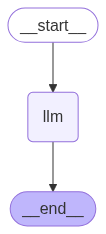

In [8]:
display_graph(graph)

In [9]:
from langchain_core.messages import SystemMessage, HumanMessage
messages = [
    SystemMessage("You are an helpful assistant"),
    HumanMessage("I would like to know about democracy")

]
result = graph.invoke({"messages": messages})

In [10]:
result['messages']

[SystemMessage(content='You are an helpful assistant', additional_kwargs={}, response_metadata={}, id='1a18fbc9-d878-4b22-8453-c0ce895970b5'),
 HumanMessage(content='I would like to know about democracy', additional_kwargs={}, response_metadata={}, id='7b499db1-1f74-4e20-a473-a93184db1e4e'),
 AIMessage(content='Democracy, at its heart, is a system of government where the ultimate power is vested in the people, who exercise it either directly or through elected representatives. It\'s often summarized by Abraham Lincoln\'s famous phrase: "government of the people, by the people, for the people."\n\nLet\'s break it down:\n\n### 1. Definition and Core Idea\n\n*   **"Demos" (people) + "Kratos" (power/rule)** = Rule by the people.\n*   The fundamental principle is **popular sovereignty**, meaning the people are the ultimate source of authority.\n*   It stands in contrast to systems like monarchies (rule by a king/queen), aristocracies (rule by a nobility), oligarchies (rule by a few), or dic

In [11]:
for message in result['messages']:
    message.pretty_print()

================================ System Message ================================

You are an helpful assistant
================================ Human Message =================================

I would like to know about democracy
================================== Ai Message ==================================

Democracy, at its heart, is a system of government where the ultimate power is vested in the people, who exercise it either directly or through elected representatives. It's often summarized by Abraham Lincoln's famous phrase: "government of the people, by the people, for the people."

Let's break it down:

### 1. Definition and Core Idea

*   **"Demos" (people) + "Kratos" (power/rule)** = Rule by the people.
*   The fundamental principle is **popular sovereignty**, meaning the people are the ultimate source of authority.
*   It stands in contrast to systems like monarchies (rule by a king/queen), aristocracies (rule by a nobility), oligarchies (rule by a few), or dictatorships (